txt_files: ['results/num_genomes_2/BR_0.48_IGD_2_proof_0.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_1.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_2.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_3.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_4.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_5.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_6.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_7.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_8.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_9.txt', 'results/num_genomes_2/BR_0.48_IGD_2_proof_10.txt']


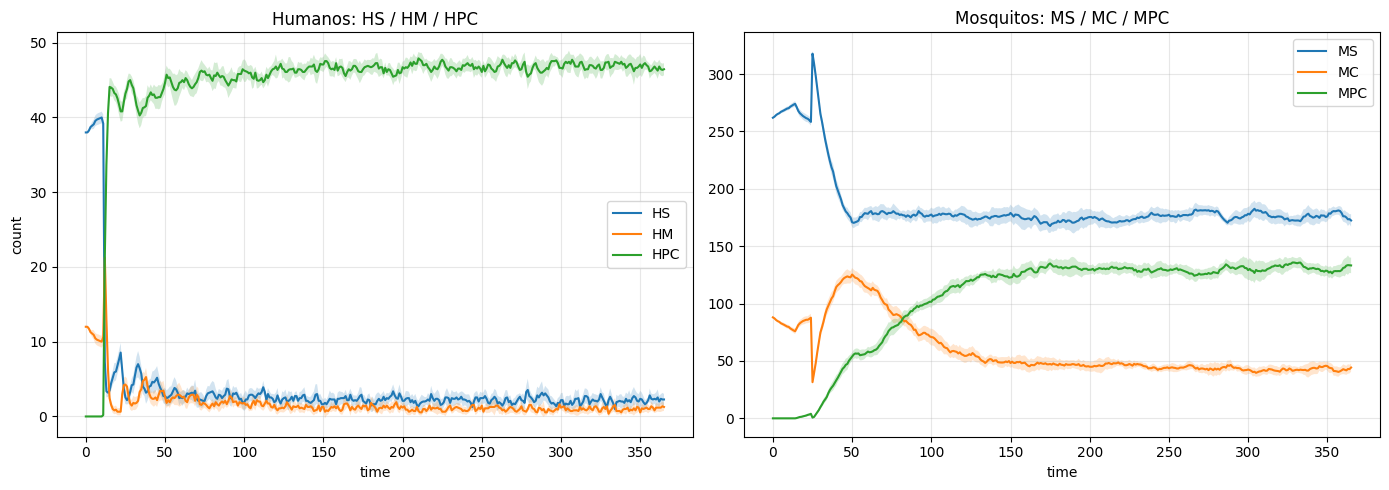

In [1]:
# ====== Parte 1: TXT -> dinámica poblacional con IC95% (múltiples archivos) ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple
import os

name_alternative = "num_genomes_2"
# ---------- Configura aquí tus archivos TXT ----------
# Puedes listar a mano o usar glob: list(Path(".").glob("BR_*_proof.txt"))
folder = "results/" + name_alternative
txt_files = []

for f in os.listdir(folder):
    if f.endswith(".txt"):
        txt_files.append(os.path.join(folder, f))

# Ordenar por el número al final, si siguen el patrón *_proof_X.txt
txt_files.sort(key=lambda x: int(x.split("_")[-1].replace(".txt","")))

print("txt_files:", txt_files)

# ---------- Helpers ----------
def load_txt(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=';')
    req = ['time', 'HS', 'HM', 'HPC', 'MS', 'MC', 'MPC']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en {path}: {missing}")
    return df[req].copy()

def nanmean_ci95(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    mat: shape (n_runs, T) con NaN para padding.
    Devuelve (mean, lo, hi) con IC95% por tiempo.
    """
    m = np.nanmean(mat, axis=0)
    s = np.nanstd(mat, axis=0, ddof=1)  # ddof=1 -> std muestral
    n = np.sum(~np.isnan(mat), axis=0).astype(float)
    se = np.where(n > 1, s / np.sqrt(n), 0.0)
    ci = 1.96 * se
    return m, m - ci, m + ci

def stack_runs(series_list: List[np.ndarray]) -> np.ndarray:
    """Apila listas 1D con distinto largo en una matriz (n_runs, T_max) con NaN padding."""
    T = max(len(s) for s in series_list)
    M = np.full((len(series_list), T), np.nan, dtype=float)
    for i, s in enumerate(series_list):
        M[i, :len(s)] = s
    return M

def aggregate_txt(files: List[str]) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    """
    Devuelve dict con claves de estado:
      'H' -> (x, mean, lo, hi) agregando HS, HM, HPC por separado (misma x)
      'M' -> (x, mean, lo, hi) agregando MS, MC, MPC por separado (misma x)
    En realidad devuelve por CADA estado: HS, HM, HPC, MS, MC, MPC.
    """
    states = ['HS', 'HM', 'HPC', 'MS', 'MC', 'MPC']
    per_state = {k: [] for k in states}
    xs = []

    for f in files:
        df = load_txt(f)
        xs.append(df['time'].to_numpy())
        for k in states:
            per_state[k].append(df[k].to_numpy(dtype=float))

    # Eje de tiempo unificado: 0..Tmax usando padding por NaN
    T = max(x.size for x in xs)
    x = np.arange(T)

    out = {}
    for k, lst in per_state.items():
        M = stack_runs(lst)  # (n_runs, T)
        mean, lo, hi = nanmean_ci95(M)
        out[k] = (x, mean, lo, hi)
    return out

def plot_ci(ax, x, mean, lo, hi, label):
    ax.plot(x, mean, label=label)
    ax.fill_between(x, lo, hi, alpha=0.2)

# ---------- Agregación y gráficos ----------
agg = aggregate_txt(txt_files)

fig, (ax_h, ax_m) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
# Humanos
for k in ['HS', 'HM', 'HPC']:
    x, mean, lo, hi = agg[k]
    plot_ci(ax_h, x, mean, lo, hi, k)
ax_h.set_title("Humanos: HS / HM / HPC")
ax_h.set_xlabel("time")
ax_h.set_ylabel("count")
ax_h.grid(True, alpha=0.3)
ax_h.legend()

# Mosquitos
for k in ['MS', 'MC', 'MPC']:
    x, mean, lo, hi = agg[k]
    plot_ci(ax_m, x, mean, lo, hi, k)
ax_m.set_title("Mosquitos: MS / MC / MPC")
ax_m.set_xlabel("time")
ax_m.grid(True, alpha=0.3)
ax_m.legend()

plt.tight_layout()
plt.savefig("fig_1_" + name_alternative + ".jpg", dpi = 400 , bbox_inches = "tight")
plt.show()


pkl_files: ['results/num_genomes_2/tmp_results_proof_1.pkl', 'results/num_genomes_2/tmp_results_proof_2.pkl', 'results/num_genomes_2/tmp_results_proof_8.pkl', 'results/num_genomes_2/tmp_results_proof_3.pkl', 'results/num_genomes_2/tmp_results_proof_6.pkl', 'results/num_genomes_2/tmp_results_proof_5.pkl', 'results/num_genomes_2/tmp_results_proof_4.pkl', 'results/num_genomes_2/tmp_results_proof_9.pkl', 'results/num_genomes_2/tmp_results_proof_0.pkl', 'results/num_genomes_2/tmp_results_proof_7.pkl', 'results/num_genomes_2/tmp_results_proof_10.pkl']


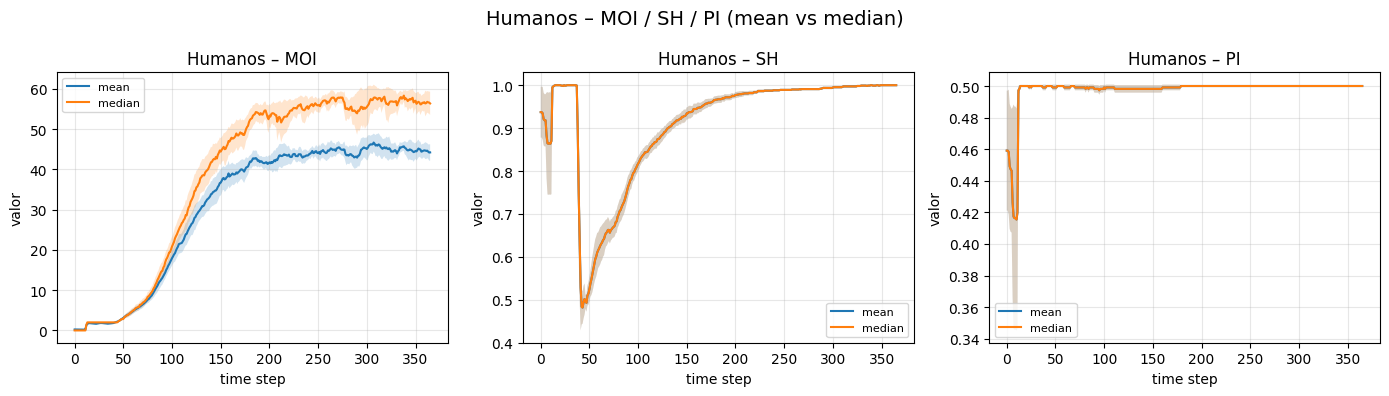

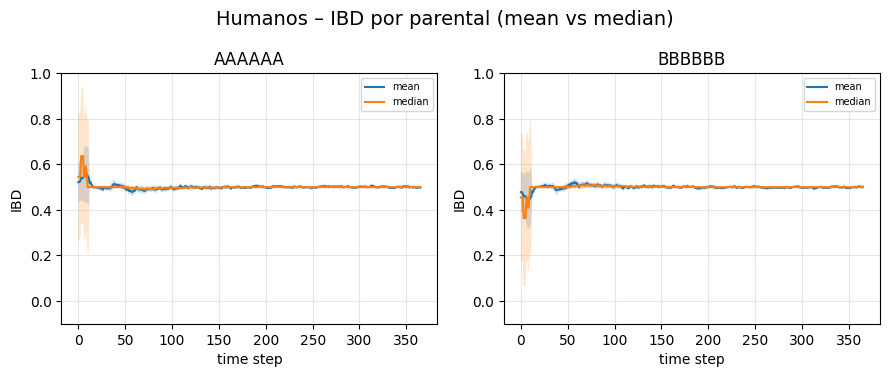

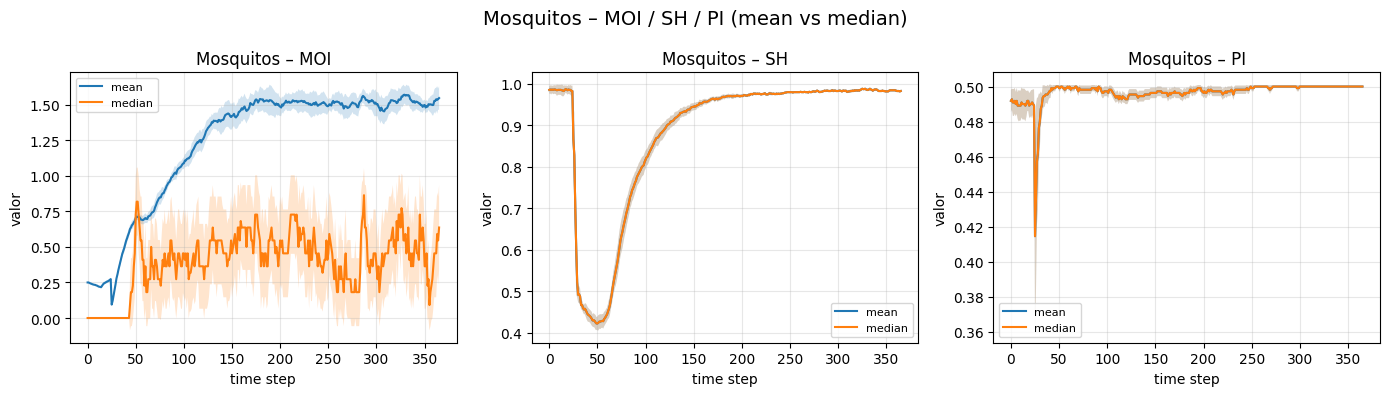

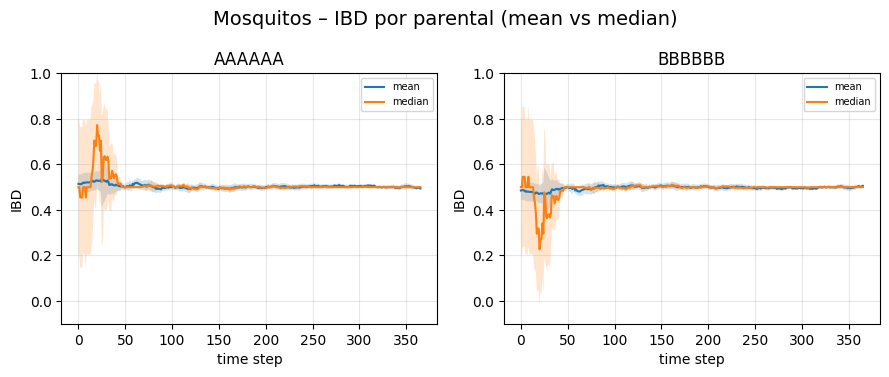

In [2]:
# ====== Parte 2: PKL -> indicadores (mean vs median) ======
#   - Por especie:
#       * 1×3: MOI, SH, PI   (mean vs median, IC95%)
#       * 1×N: IBD por parental (mean vs median, IC95%)
#
#   Notas:
#   - Soporta múltiples .pkl (agrega entre runs alineando 0..N-1 con NaN padding).
#   - Para IBD, se traza una subgráfica por parental encontrado en los archivos.

import pickle
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Tuple, Optional, Set

# ==== Archivos PKL (ajusta a tus rutas) ====
import os

pkl_files = []

for f in os.listdir(folder):
    if f.endswith(".pkl"):
        pkl_files.append(os.path.join(folder, f))

print("pkl_files:", pkl_files)

# ==== Indicadores no-IBD que van en la 1×3 ====
METRICS_NON_IBD = ["MOI", "SH", "PI"]


# ---------- Helpers de IO ----------
def load_pkl(path: str) -> Dict[str, Any]:
    with open(path, "rb") as f:
        d = pickle.load(f)
    if not isinstance(d, dict):
        raise TypeError(f"{path}: PKL debe contener un dict.")
    return d


# ---------- Estadísticos ----------
def stack_runs(series_list: List[np.ndarray]) -> np.ndarray:
    """Apila listas 1D con distinto largo en una matriz (n_runs, T) con NaN padding."""
    T = max(len(s) for s in series_list)
    M = np.full((len(series_list), T), np.nan, dtype=float)
    for i, s in enumerate(series_list):
        M[i, :len(s)] = s
    return M

def nanmean_ci95(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Media y banda de IC95% por columna, ignorando NaNs."""
    m = np.nanmean(mat, axis=0)
    s = np.nanstd(mat, axis=0, ddof=1)
    n = np.sum(~np.isnan(mat), axis=0).astype(float)
    se = np.where(n > 1, s / np.sqrt(n), 0.0)
    ci = 1.96 * se
    return m, m - ci, m + ci


# ---------- Extracción de series ----------
def extract_series_non_ibd(block: Dict[str, Any], metric: str) -> Optional[List[float]]:
    """Extrae MOI/SH/PI como lista."""
    if metric not in block:
        return None
    s = block[metric]
    if isinstance(s, list):
        return s
    return None

def list_parentals_for_species(pkl_paths: List[str], species_keys: List[str]) -> Set[str]:
    """
    Une todos los parentales (claves de IBD) presentes en los archivos para las keys de especie dadas.
    species_keys típicamente: ["humans_mean","humans_median"] o ["mosquitoes_mean","mosquitoes_median"].
    """
    parentals: Set[str] = set()
    for p in pkl_paths:
        d = load_pkl(p)
        for sk in species_keys:
            ibd_block = d.get(sk, {}).get("IBD", {})
            if isinstance(ibd_block, dict):
                parentals.update(ibd_block.keys())
    return parentals

def extract_series_ibd_parental(block: Dict[str, Any], parental: str) -> Optional[List[float]]:
    """Extrae la serie de IBD para un parental específico."""
    ibd = block.get("IBD", {})
    if not isinstance(ibd, dict):
        return None
    s = ibd.get(parental)
    if isinstance(s, list):
        return s
    return None


# ---------- Agregadores entre archivos ----------
def aggregate_metric(pkl_paths: List[str], species_key: str, metric: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Agrega un indicador 'metric' (no IBD) para species_key (p.ej., 'humans_mean').
    Devuelve x, mean, lo, hi.
    """
    series = []
    for p in pkl_paths:
        d = load_pkl(p)
        block = d.get(species_key, {})
        s = extract_series_non_ibd(block, metric)
        if s is None:
            continue
        series.append(np.asarray(s, dtype=float))
    if not series:
        return np.array([]), np.array([]), np.array([]), np.array([])
    M = stack_runs(series)
    m, lo, hi = nanmean_ci95(M)
    x = np.arange(m.size)
    return x, m, lo, hi

def aggregate_ibd_parental(pkl_paths: List[str], species_key: str, parental: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Agrega la serie IBD de un 'parental' específico para species_key (p.ej., 'humans_mean').
    """
    series = []
    for p in pkl_paths:
        d = load_pkl(p)
        block = d.get(species_key, {})
        s = extract_series_ibd_parental(block, parental)
        if s is None:
            continue
        series.append(np.asarray(s, dtype=float))
    if not series:
        return np.array([]), np.array([]), np.array([]), np.array([])
    M = stack_runs(series)
    m, lo, hi = nanmean_ci95(M)
    x = np.arange(m.size)
    return x, m, lo, hi


# ---------- Plot helpers ----------
def plot_mean_median_subplot(ax, metric: str,
                             data_mean: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
                             data_median: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
                             title_prefix: str,
                             y_label: str = "valor"):
    x_m, mean_m, lo_m, hi_m = data_mean
    x_md, mean_md, lo_md, hi_md = data_median

    if x_m.size == 0 and x_md.size == 0:
        ax.set_title(f"{title_prefix} – {metric} (sin datos)")
        ax.axis("off")
        return

    if x_m.size > 0:
        ax.plot(x_m, mean_m, label="mean")
        ax.fill_between(x_m, lo_m, hi_m, alpha=0.2)
    if x_md.size > 0:
        ax.plot(x_md, mean_md, label="median")
        ax.fill_between(x_md, lo_md, hi_md, alpha=0.2)

    ax.set_title(f"{title_prefix} – {metric}")
    ax.set_xlabel("time step")
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


def plot_species_non_ibd_1x3(species_label: str, key_mean: str, key_median: str):
    """Dibuja una fila 1×3 para MOI, SH, PI (mean vs median) de una especie."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    for ax, metric in zip(axes, METRICS_NON_IBD):
        data_mean   = aggregate_metric(pkl_files, key_mean, metric)
        data_median = aggregate_metric(pkl_files, key_median, metric)
        plot_mean_median_subplot(ax, metric, data_mean, data_median, species_label)
    fig.suptitle(f"{species_label} – MOI / SH / PI (mean vs median)", y=0.98, fontsize=14)
    plt.tight_layout()
    plt.savefig("fig_2_" + name_alternative +  "_" + species_label +".jpg", dpi = 400 , bbox_inches = "tight")

    plt.show()

def plot_species_ibd_1xN(species_label: str, key_mean: str, key_median: str):
    """Dibuja una fila 1×N (N=parentales) para IBD (mean vs median) de una especie."""
    # Parentales presentes en alguno de los archivos para mean/median de esta especie:
    parentals = sorted(list_parentals_for_species(pkl_files, [key_mean, key_median]))
    N = len(parentals)

    if N == 0:
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        ax.set_title(f"{species_label} – IBD (sin parentales)")
        ax.axis("off")
        plt.show()
        return

    # Crear 1×N (manejar caso N==1 para que axes sea un array)
    fig, axes = plt.subplots(1, N, figsize=(4.5 * N, 3.8))
    if N == 1:
        axes = np.array([axes])

    for ax, parental in zip(axes, parentals):
        data_mean   = aggregate_ibd_parental(pkl_files, key_mean, parental)
        data_median = aggregate_ibd_parental(pkl_files, key_median, parental)

        x_m, mean_m, lo_m, hi_m = data_mean
        x_md, mean_md, lo_md, hi_md = data_median

        if x_m.size == 0 and x_md.size == 0:
            ax.set_title(f"{parental} (sin datos)")
            ax.axis("off")
            continue

        if x_m.size > 0:
            ax.plot(x_m, mean_m, label="mean")
            ax.fill_between(x_m, lo_m, hi_m, alpha=0.2)
        if x_md.size > 0:
            ax.plot(x_md, mean_md, label="median")
            ax.fill_between(x_md, lo_md, hi_md, alpha=0.2)

        ax.set_title(str(parental))
        ax.set_xlabel("time step")
        ax.set_ylabel("IBD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_ylim(-0.1,1)

    fig.suptitle(f"{species_label} – IBD por parental (mean vs median)", y=0.98, fontsize=14)
    plt.tight_layout()
    plt.savefig("fig_3_" + name_alternative + ".jpg", dpi = 400 , bbox_inches = "tight")
    plt.show()


# =======================
#     GRAFICAR
# =======================

# HUMANOS: 1×3 y 1×N
plot_species_non_ibd_1x3("Humanos", "humans_mean", "humans_median")
plot_species_ibd_1xN("Humanos", "humans_mean", "humans_median")

# MOSQUITOS: 1×3 y 1×N
plot_species_non_ibd_1x3("Mosquitos", "mosquitoes_mean", "mosquitoes_median")
plot_species_ibd_1xN("Mosquitos", "mosquitoes_mean", "mosquitoes_median")